# Contrast Response Demo: Gratings

Split out of `7_contrast_response_demo.ipynb` (grating section only) -- see
`changes/notebook_reorg_2026-08-10.md`. Flash has its own notebook
(`5_flash_demo.ipynb`); spots are excluded for now (no example spot-contrast data
yet, so no notebook for it).

To look through the raster/CRF plotting functions, refer to
`src/retinanalysis/utils/contrast_response_utils.py`.

**What this notebook gives you:**
- CRF curves: raw and noise-subtracted, non-normalized and per-cell-normalized (4
  panels), population mean +/- SEM vs. contrast. Uses F1 (periodic stimulus).
- Noise subtraction: baseline is the per-cell average F1/mean-rate from this
  experiment's own 0%-contrast trials (see UPDATE below), not a pre-stimulus window.
- Rasters, two ways: an overview grid with one representative cell per cell type,
  and a "pick a cell type, see every cell of that type" browser.
- Raster+PSTH pairing (sanity check that the PSTH curve is a fair summary of the
  raw spikes above it).
- Naka-Rushton fit for a single example cell.

`corr_cutoff` (the EI-matching threshold, MATLAB's `corr_threshold`) is a real,
settable parameter on `create_mea_pipeline`/`MEAPipeline` -- `CORR_THRESHOLD_GRATING`
below, defaulting to 0.85.

**UPDATED 2026-08-10 (item 3a):** noise subtraction now uses
`baseline_condition_key='contrast'` (0%-contrast trials) instead of each trial's
pre-stimulus window -- see `build_trial_response_table`'s docstring
(`tuning.py`) for the full reasoning. This also fixes the short-window statistical
bias that used to make `f1_noise_sub` come out spuriously negative (the CAVEAT that
used to be here), so the CRF cells below now show noise-subtracted F1
(`show_noise_sub=True`) alongside raw F1, instead of hiding it.

See `changes/grating_and_contrast_demos_notes.md` for the full history of this
content from when it lived in the combined notebook.


In [1]:
import retinanalysis as ra
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


C:\Users\Yasmine Tani\anaconda3\envs\retinanalysis\Lib\site-packages\datajoint\settings.py:992: UserWarning: No datajoint.json found. Using defaults and environment variables. Run `dj.config.save_template()` to create a template configuration.
  config = _create_config()


## Find contrast-response datasets

Broad substring search (`'contrast'`) -- deliberately not exact-match, since spot
and flash protocol names aren't confirmed yet. Check the printed
`protocol_name`s below and fill in each section's `_PROTOCOL_NAME` variable
accordingly.

In [2]:
contrast_search = ra.get_datasets_from_protocol_names('contrast')
print(contrast_search['protocol_name'].unique())
display(contrast_search)


[2026-08-11 16:57:23] DataJoint 2.2.2 connected to root@127.0.0.1:3306

Found 3 protocols matching "contrast":
['manookinlab.protocols.ContrastResponseFlash'
 'manookinlab.protocols.ContrastResponseGrating'
 'manookinlab.protocols.ContrastResponseSpot']

Found 22 experiments, 195 epoch blocks.

<StringArray>
[   'manookinlab.protocols.ContrastResponseSpot',
   'manookinlab.protocols.ContrastResponseFlash',
 'manookinlab.protocols.ContrastResponseGrating']
Length: 3, dtype: str


,exp_name,datafile_name,NDF,chunk_name,protocol_name,is_mea,data_dir,group_label,experiment_id,protocol_id,group_id,block_id,chunk_id
0,20250912A,data009,3.0,data009,manookinlab.protocols.ContrastResponseSpot,1,20250912A\data009,Control,353,6,1257,3678,3262
1,20250918A,data004,5.0,data004,manookinlab.protocols.ContrastResponseSpot,1,20250918A\data004,Control,354,6,1258,3683,3267
2,20250918A,data008,4.0,data008,manookinlab.protocols.ContrastResponseSpot,1,20250918A\data008,Control,354,6,1258,3687,3271
3,20250918A,data012,3.0,data012,manookinlab.protocols.ContrastResponseSpot,1,20250918A\data012,Control,354,6,1258,3691,3275
4,20250918A,data016,2.0,data016,manookinlab.protocols.ContrastResponseSpot,1,20250918A\data016,Control,354,6,1258,3695,3279
...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,20260724A,data000,5.0,data000,manookinlab.protocols.ContrastResponseGrating,1,20260724A\data000,NDF5,382,8,1371,4049,3651
191,20260724A,data001,4.0,data001,manookinlab.protocols.ContrastResponseGrating,1,20260724A\data001,NDF4,382,8,1372,4050,3652
192,20260724A,data004,3.0,data004,manookinlab.protocols.ContrastResponseGrating,1,20260724A\data004,NDF3,382,8,1373,4053,3655
193,20260724A,data007,2.0,data007,manookinlab.protocols.ContrastResponseGrating,1,20260724A\data007,NDF2,382,8,1374,4056,3658


## Choose an experiment (shared across all sections)

Only `exp_name` needs to be set. The white-noise/cell-typing chunk is found once
here (`ra.find_classified_noise_chunk`, same picker as the DS/OS demo -- prefers
a classified NDF0 chunk, falls back to NDF1, prints what it found) and reused by
every section below, since cell typing doesn't depend on which contrast stimulus
is being analyzed. Set `MANUAL_ANALYSIS_CHUNK` to override.

In [3]:
exp_name = '20260313A'

MANUAL_ANALYSIS_CHUNK = None  # e.g. 'chunk13' or 'data001' -- set this to skip auto-detection

analysis_chunk_name = MANUAL_ANALYSIS_CHUNK or ra.find_classified_noise_chunk(exp_name)
if analysis_chunk_name is None:
    print(
        'No classified NDF0/NDF1 white-noise chunk found -- each section below will '
        'fall back to create_mea_pipeline\'s own nearest-chunk logic. This may crash; '
        'if so, set MANUAL_ANALYSIS_CHUNK above to a chunk you know is classified.'
    )


20260313A: using data012 (NDF 0, classification file(s): ['data012.classificationYT.txt']).
  Stimulus parameters for data012:
    NDF: 0.0
    alpha: 1.0
    amp: Amp1
    amp2: (None)
    appVersion: None
    backgroundIntensity: 0.5
    canvasSize: [1824.0, 1140.0]
    centerOffset: [0.0, 0.0]
    chromaticClass: achromatic
    contrast: 1.0
    dataFileName: 20260313A\data012.bin
    dspVersion: None
    expectedRefreshRate: 59.94
    externalCommandSensitivity: 0.02
    externalCommandSensitivityUnits: V_V
    filterSdStixels: 1.0
    firmwareVersion: None
    frameDwell: 4.0
    frameDwells: [4.0, 4.0]
    frameRate: 59.0
    gaussianFilter: 0
    gridSize: 20.0
    hardwareType: MCTG_HW_TYPE_MC700B
    interpulseInterval: 0.5
    lightCrafterLedCurrents: [104.0, 135.0, 130.0]
    lightCrafterLedEnables: [1, 0, 0, 0]
    lightPath: below
    local_movie_directory: C:\Users\Public\Documents\GitRepos\Symphony2\movies\
    lpfCutoff: 10000.0
    membraneCapacitance: 0.0
    micronsP

## Load cell typing (shared across all sections)

Builds an `AnalysisChunk` for the chunk found above just to read its
classification file(s) -- `b_load_spatial_maps=False`/`include_ei=False` since
none of this notebook needs RF maps or EIs, only the cell_id -> cell_type
mapping. If the chunk has more than one classification file, the first one found
is used by default; set `PREFERRED_TYPING_FILE` to pick a specific one.

In [4]:
PREFERRED_TYPING_FILE = None  # e.g. 'chunk13.classificationYT.txt' -- set to pick a specific file

cell_type_map = pd.Series(dtype=object)

if analysis_chunk_name is not None:
    # NOTE (RTMP tag / "Globals file does not have RTMP tag" errors):
    # Some chunks' .globals files are missing the RTMP (runtime movie parameters) tag
    # that Vision normally writes. That tag is only used to correct for STA-vs-noise-grid
    # cropping (deltaXChecks/deltaYChecks in AnalysisChunk.get_noise_params()). When the
    # tag is missing, retinanalysis now falls back to assuming NO cropping occurred
    # (staXChecks = numXChecks, staYChecks = numYChecks, delta = 0) instead of crashing,
    # and prints a warning whenever this happens. This assumption is based on my old
    # MATLAB pipeline never needing the globals file/RTMP for this correction and never
    # having this issue -- consistent with our white-noise protocol not actually cropping
    # the STA relative to the full noise grid. If cell RF center positions ever look off
    # for a chunk that hit this warning, that assumption is the first thing to revisit.
    typing_chunk = ra.AnalysisChunk(
        exp_name, analysis_chunk_name, b_load_spatial_maps=False, include_ei=False, verbose=False,
    )
    classification_files = [f for f in typing_chunk.typing_files if 'classification' in f.lower()]
    if not classification_files:
        print(f'{analysis_chunk_name} has no classification file -- cell_type will be "Unknown" for every cell.')
    else:
        chosen_file = (
            PREFERRED_TYPING_FILE if PREFERRED_TYPING_FILE in classification_files
            else classification_files[0]
        )
        if len(classification_files) > 1:
            print(f'Multiple classification files found: {classification_files}. Using {chosen_file}.')
        file_idx = typing_chunk.typing_files.index(chosen_file)
        cell_type_map = pd.Series(
            typing_chunk.df_cell_params[f'typing_file_{file_idx}'].values,
            index=typing_chunk.cell_ids,
        )
        print(f'Loaded cell types for {len(cell_type_map)} cells from {chosen_file}.')
        print(cell_type_map.value_counts())

        # If most cells are "Unknown", the likely cause is that
        # src/retinanalysis/assets/cell_types.csv (the reference vocabulary cell-type
        # labels get matched against) is mostly a primate cell-type list, with only a few
        # mouse types patched in ('on/brisk sustained', 'on/brisk transient',
        # 'brisk sustained' -- note the '/' and the missing 'off' variants). If your
        # classification file's real labels don't exactly match an entry in that CSV,
        # matching fails silently and everything becomes "Unknown". This prints the raw
        # label text actually found in the classification file for a few cells, plus the
        # current cell_types.csv vocabulary, so the mismatch (if there is one) is visible.
        if len(cell_type_map) > 0 and (cell_type_map == 'Unknown').mean() > 0.5:
            print()
            print('Over half of cells are "Unknown" -- likely a cell_types.csv vocabulary '
                  'mismatch, not a real absence of classifications.')
            typing_file_path = typing_chunk._resolve_typing_file_path(chosen_file)
            if typing_file_path is not None:
                print(f'Raw lines from {typing_file_path}:')
                with open(typing_file_path, 'r') as f:
                    raw_lines = [line.strip() for line in f if line.strip()][:5]
                for line in raw_lines:
                    print(f'  {line!r}')
            else:
                print(f'Could not resolve a file path for {chosen_file} to show raw content.')
            import importlib.resources as ir
            import retinanalysis
            cell_types_csv_path = str(ir.files(retinanalysis) / 'assets/cell_types.csv')
            with open(cell_types_csv_path, 'r') as f:
                csv_entries = [l.strip() for l in f if l.strip() and l.strip() != 'cell_types']
            print(f'Current assets/cell_types.csv vocabulary ({len(csv_entries)} entries): {csv_entries}')
else:
    print('No analysis_chunk_name -- skipping cell typing, every cell will show as "Unknown".')


[data012.classificationYT.txt] 13 raw classification token(s) did not match any cell_types.csv entry (even after normalizing hyphens/underscores/extra spaces) and were classified 'Unknown': ['large', 'nc0', 'nc10', 'nc11', 'nc18', 'nc3', 'nc4', 'nc5', 'nc6', 'nc7', 'nc8', 'unclassified', 'weak']
Loaded cell types for 326 cells from data012.classificationYT.txt.
Unknown                285
on/brisk sustained      15
off/brisk sustained      9
off/brisk transient      9
off/transient            8
Name: count, dtype: int64

Over half of cells are "Unknown" -- likely a cell_types.csv vocabulary mismatch, not a real absence of classifications.
Raw lines from B:\Array-data\sorted\20260313A\kilosort25\data012\data012.classificationYT.txt:
  '1  All/off/unclassified/'
  '7  All/off/unclassified/'
  '14  All/off/unclassified/'
  '27  All/off/unclassified/'
  '62  All/off/unclassified/'
Current assets/cell_types.csv vocabulary (39 entries): ['OnP', 'OffP', 'LOnM', 'MOnM', 'OnM', 'BlueOffM', 'LOff

## Shared response-extraction and plotting functions

Defined in `src/retinanalysis/utils/contrast_response_utils.py` and imported below; used
by all three sections.

- `load_contrast_section(...)`: finds the datafile for a given protocol (via
  `ra.find_datafile_for_protocol`), builds the pipeline (reusing the shared
  `analysis_chunk_name` from above, with a settable `corr_cutoff` EI-matching threshold),
  builds the tidy response table (via `ra.build_trial_response_table`), tags each row with
  its `cell_type` (from `pipeline.resp.df_spike_times`, via `MEAPipeline`'s own EI-based
  cross-chunk cell mapping), and prints `epoch_parameters` keys for verification.
- `plot_crf(...)`: raw vs. noise-subtracted (rows, `show_noise_sub=False` to skip the
  noise-subtracted row) x non-normalized vs. per-cell-normalized (cols) -- population mean
  +/- SEM vs. condition.
- `plot_raster_overview_by_cell_type(...)` / `plot_rasters_for_cell_type(...)`: one figure
  PER cell type (not one combined grid) with a representative sample of cells, and every
  cell of a chosen type, paginated.

**Cell-type bookkeeping labels:** `'Unmatched'` means a cell never EI-matched the reference
classification chunk at all; `'Unknown'` means it matched but its classification label was
blank/unrecognized. Both are excluded from cell-type lists by default -- if most cells come
out "Unknown", check whether `assets/cell_types.csv` has your lab's actual mouse cell-type
vocabulary (see the typing cell above).


In [5]:
# Shared response-extraction and plotting functions for this notebook live in
# src/retinanalysis/utils/contrast_response_utils.py, not in this cell -- this just imports
# them under their bare names, so every other cell that calls
# load_contrast_section(...)/plot_crf(...)/etc. needs no changes. Edit that file to change
# what these functions do, then re-run this cell (or restart the kernel) to pick up the
# change.
from retinanalysis.utils.contrast_response_utils import *


---
# Section: Gratings (`ContrastResponseGrating`)

Protocol name confirmed from earlier real search results:
`manookinlab.protocols.ContrastResponseGrating`. Periodic stimulus (has
`temporalFrequency`), so this section uses F1 as the response measure --
`f1`/`f1_noise_sub` from `build_trial_response_table`.

In [6]:
GRATING_PROTOCOL_NAME = 'manookinlab.protocols.ContrastResponseGrating'
MANUAL_DATAFILE_NAME_GRATING = None  # e.g. 'data015' -- set to skip auto-detection
CORR_THRESHOLD_GRATING = 0.85  # EI-matching cutoff (reference chunk <-> this datafile)

# load_contrast_section's progress/diagnostic prints (epoch counts, epoch_parameters
# keys, cell-count funnel, etc.) are collapsed into one small scrollable box by
# scrollable_prints() -- doesn't change anything about the loaded data.
with scrollable_prints():
    df_trials_grating, spike_times_by_cell_grating, df_epochs_grating, datafile_name_grating, ndf_grating = load_contrast_section(
        exp_name, contrast_search, GRATING_PROTOCOL_NAME, condition_keys=['contrast'],
        analysis_chunk_name=analysis_chunk_name, corr_cutoff=CORR_THRESHOLD_GRATING,
        manual_datafile_name=MANUAL_DATAFILE_NAME_GRATING, typing_chunk=typing_chunk,
        baseline_condition_key='contrast', baseline_condition_value=0.0,
    )


## Grating CRF (F1-based)

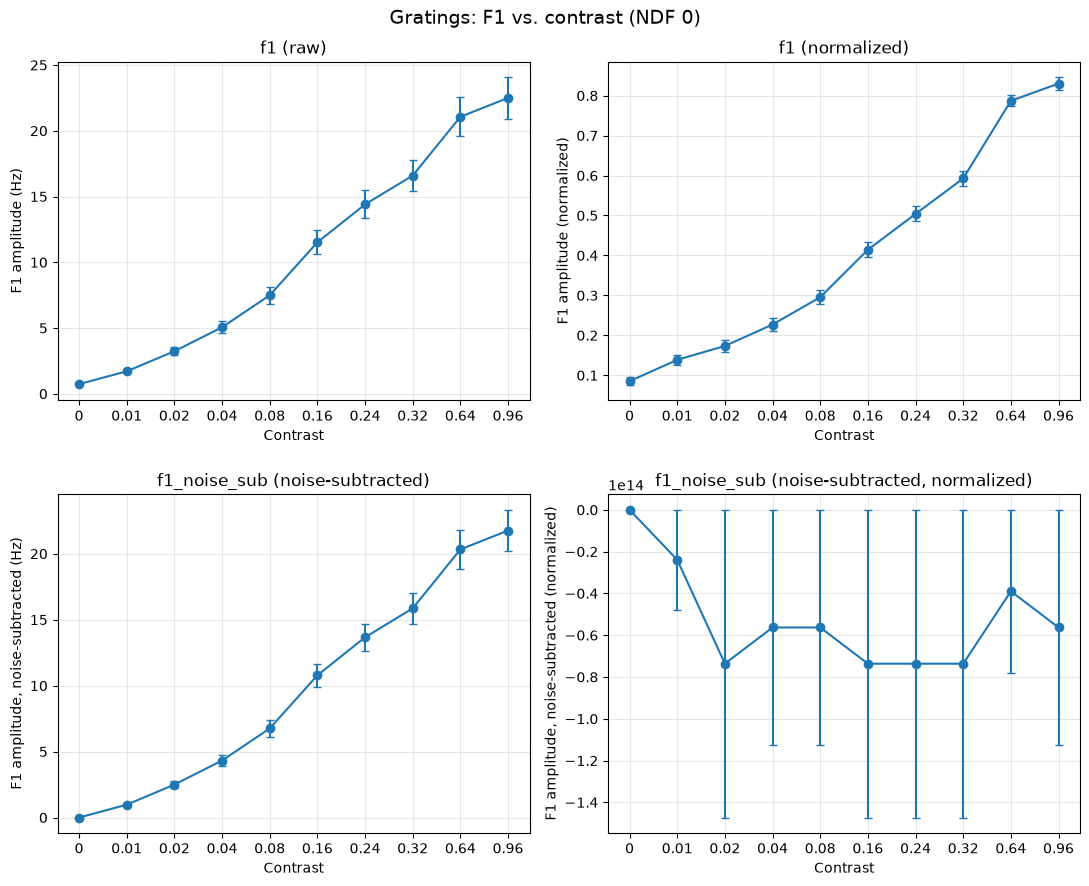

In [7]:
# UPDATED 2026-08-10 (Claude, per yas, item 3a): now shows the noise-subtracted row
# too (show_noise_sub=True). Previously this was False because 'f1_noise_sub' had a
# real short-window statistical bias -- see the CAVEAT in build_trial_response_table's
# docstring (tuning.py) -- that made it come out spuriously negative for every cell.
# baseline_condition_key='contrast' below sidesteps that bias entirely: noise_f1 is
# now the per-cell average F1 from the actual 0%-contrast trials (same window length
# as every other condition), not a short pre-stimulus window, so 'f1_noise_sub' is
# trustworthy now. Both rows use the SAME df_trials_grating (loaded once, above, with
# baseline_condition_key='contrast' already set) -- raw 'f1' is still shown too, for
# comparison against the pre-change convention yas's own MATLAB scripts use.
# log_x=False, even_spacing=True (per yas, 2026-08-06): linear-looking axis, real
# contrast values as labels, but evenly spaced so low (often close-together, e.g.
# 0.02/0.05/0.1) contrast levels don't visually pile up on top of each other the way
# true-to-scale linear spacing did. See plot_crf's even_spacing docstring.
fig = plot_crf(
    df_trials_grating, condition_key='contrast',
    response_col='f1_noise_sub', raw_response_col='f1',
    title=f'Gratings: F1 vs. contrast (NDF {ndf_grating})',
    show_noise_sub=True, log_x=False, even_spacing=True,
)


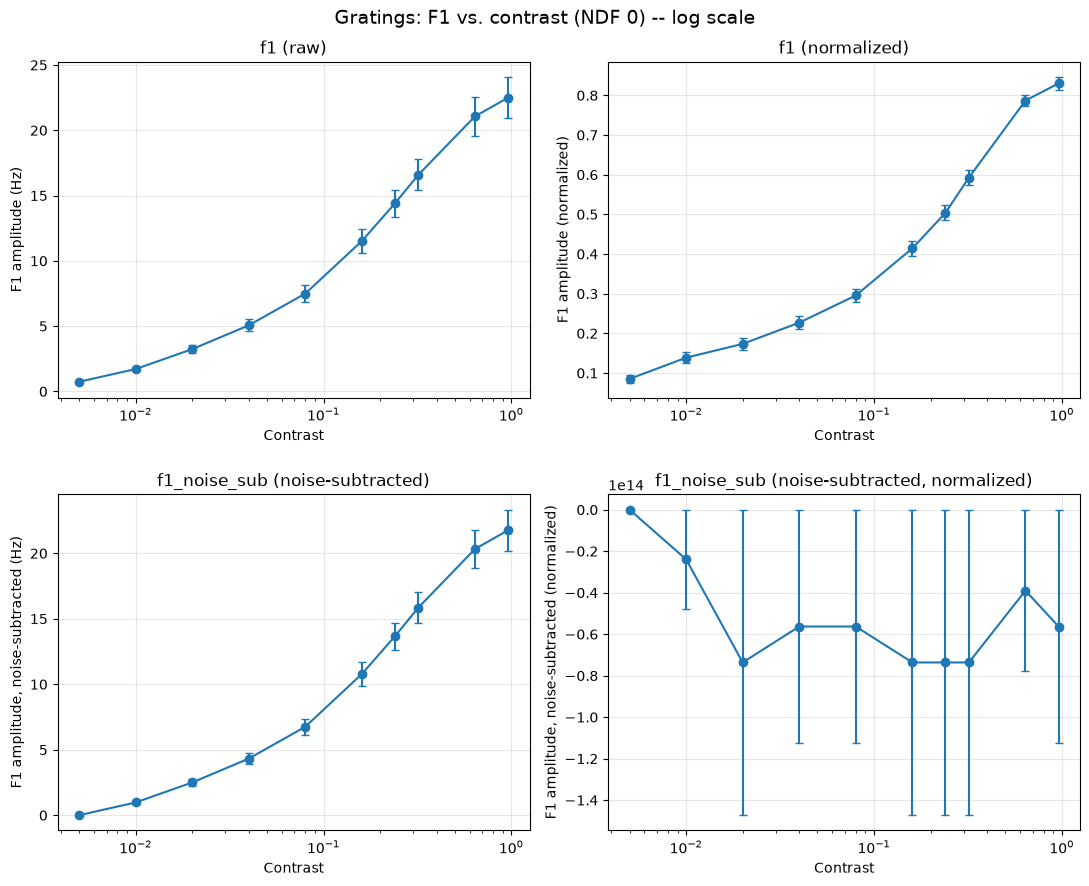

In [8]:
# Log-scale version of the plot above (per yas, 2026-08-06: "for the log scale
# one its fine to have it be scientific notation") -- same data, true-to-scale
# log-x axis instead of the evenly-spaced linear one. show_noise_sub=True for the
# same reason as the cell above (2026-08-10 update).
fig = plot_crf(
    df_trials_grating, condition_key='contrast',
    response_col='f1_noise_sub', raw_response_col='f1',
    title=f'Gratings: F1 vs. contrast (NDF {ndf_grating}) -- log scale',
    show_noise_sub=True, log_x=True,
)


### CRF across all NDFs, one figure per cell type

Loops every NDF found for `GRATING_PROTOCOL_NAME` (via `ra.get_ndf_blocks_for_protocol`,
real database NDF values, not a hardcoded list) and overlays each NDF's population CRF as
its own line/color on shared axes. Produces one figure per real cell type (auto-detected
across every loaded NDF, excluding `'Unknown'`/`'Unmatched'`) -- each figure's title names
the cell type. Uses raw `'f1'` (not noise-subtracted), same reasoning as the single-NDF
cell above. Data is loaded once per NDF (not once per NDF per type).

Reloads and re-matches cells at every NDF (same per-NDF cost as running the "explore a
different NDF" cell once per NDF below), so this can take a while -- progress prints
collapse into a scrollable box (`scrollable_prints`, in contrast_response_utils.py).

Set `SHOW_SEM_ACROSS_NDFS = False` in the cell below to hide the SEM error bars (useful but can make the plot busy with many NDFs overlaid).


20260313A: found 6 NDF level(s) for 'manookinlab.protocols.ContrastResponseGrating': [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]


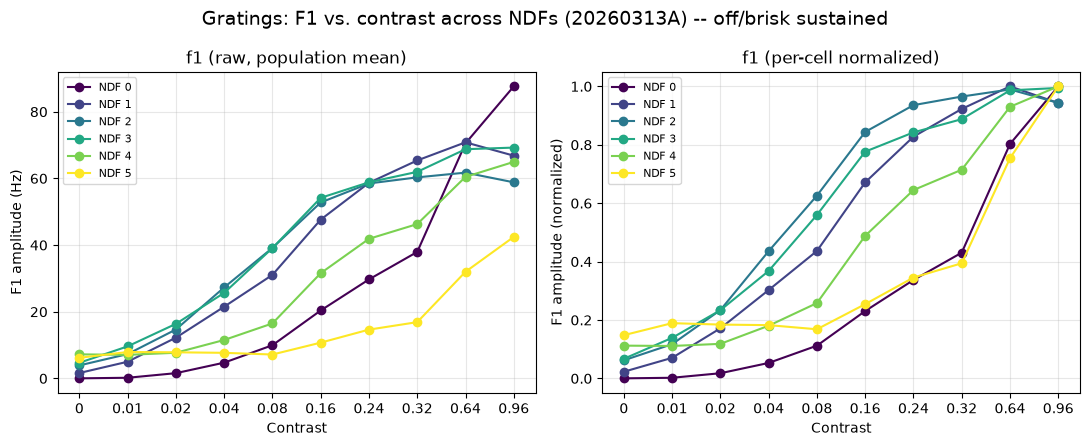

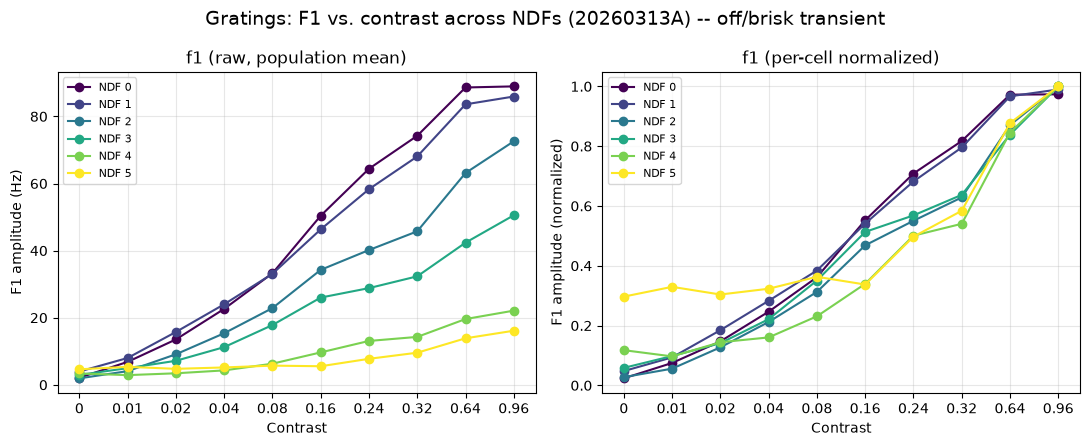

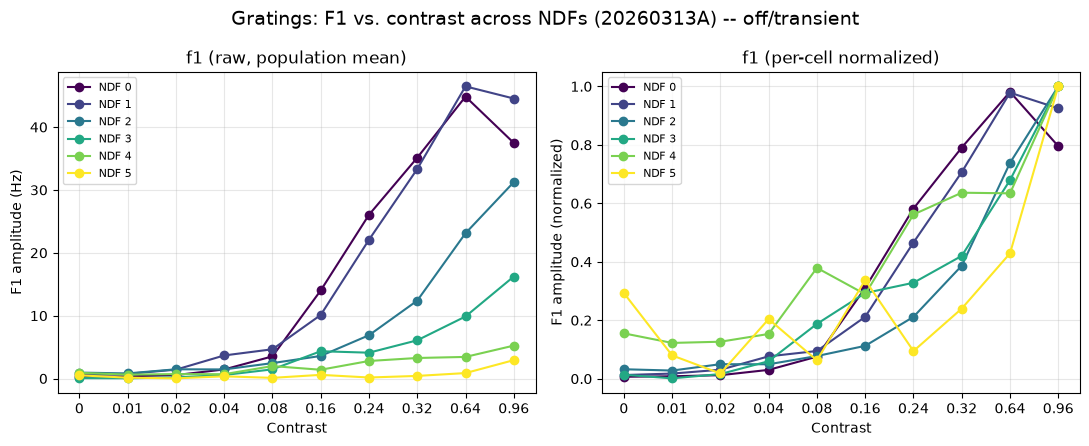

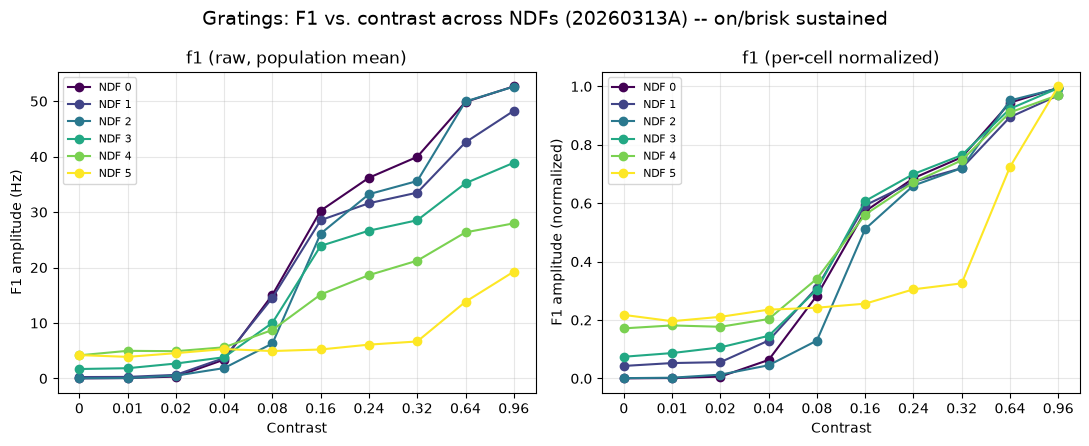

In [9]:
SHOW_SEM_ACROSS_NDFS = False  # quick on/off for the SEM error bars on these plots -- useful but can be distracting 

# Raw F1 (not noise-subtracted) -- see the noise-subtracted version of this same plot
# further down (2026-08-10 update). log_x=False, even_spacing=True (per yas,
# 2026-08-06): same evenly-spaced linear axis convention as the single-NDF CRF cell above.
figs_crf_all_ndfs_grating = plot_crf_across_ndfs(
    exp_name, contrast_search, GRATING_PROTOCOL_NAME, condition_key='contrast',
    analysis_chunk_name=analysis_chunk_name, corr_cutoff=CORR_THRESHOLD_GRATING,
    response_col='f1', typing_chunk=typing_chunk,
    baseline_condition_key='contrast', baseline_condition_value=0.0,
    title_prefix=f'Gratings: F1 vs. contrast across NDFs ({exp_name})',
    show_sem=SHOW_SEM_ACROSS_NDFS, log_x=False, even_spacing=True,
)


In [ ]:
# Log-scale version of the plot above (per yas, 2026-08-06: "for the log scale
# one its fine to have it be scientific notation") -- same data, true-to-scale
# log-x axis instead of the evenly-spaced linear one.
figs_crf_all_ndfs_grating_log = plot_crf_across_ndfs(
    exp_name, contrast_search, GRATING_PROTOCOL_NAME, condition_key='contrast',
    analysis_chunk_name=analysis_chunk_name, corr_cutoff=CORR_THRESHOLD_GRATING,
    response_col='f1', typing_chunk=typing_chunk,
    baseline_condition_key='contrast', baseline_condition_value=0.0,
    title_prefix=f'Gratings: F1 vs. contrast across NDFs ({exp_name}) -- log scale',
    show_sem=SHOW_SEM_ACROSS_NDFS, log_x=True,
)


### Noise-subtracted version of the plots above

UPDATED 2026-08-10 (per yas, catching a gap in the item 3a fix): the cells above pass
`baseline_condition_key='contrast'` to `plot_crf_across_ndfs`, so the underlying
`df_trials` for each NDF already has a correctly de-biased `f1_noise_sub` -- but they
plot `response_col='f1'` (raw), so that fix was invisible here even though it was
applied. These two cells are the same calls with `response_col='f1_noise_sub'`
instead, matching what the single-NDF CRF cells above already show
(`show_noise_sub=True`, raw and noise-subtracted side by side).


In [ ]:
figs_crf_all_ndfs_grating_noise_sub = plot_crf_across_ndfs(
    exp_name, contrast_search, GRATING_PROTOCOL_NAME, condition_key='contrast',
    analysis_chunk_name=analysis_chunk_name, corr_cutoff=CORR_THRESHOLD_GRATING,
    response_col='f1_noise_sub', typing_chunk=typing_chunk,
    baseline_condition_key='contrast', baseline_condition_value=0.0,
    title_prefix=f'Gratings: F1 (noise-subtracted) vs. contrast across NDFs ({exp_name})',
    show_sem=SHOW_SEM_ACROSS_NDFS, log_x=False, even_spacing=True,
)


In [ ]:
# Log-scale version of the plot above -- same data, true-to-scale log-x axis
# instead of the evenly-spaced linear one.
figs_crf_all_ndfs_grating_noise_sub_log = plot_crf_across_ndfs(
    exp_name, contrast_search, GRATING_PROTOCOL_NAME, condition_key='contrast',
    analysis_chunk_name=analysis_chunk_name, corr_cutoff=CORR_THRESHOLD_GRATING,
    response_col='f1_noise_sub', typing_chunk=typing_chunk,
    baseline_condition_key='contrast', baseline_condition_value=0.0,
    title_prefix=f'Gratings: F1 (noise-subtracted) vs. contrast across NDFs ({exp_name}) -- log scale',
    show_sem=SHOW_SEM_ACROSS_NDFS, log_x=True,
)


## Grating Naka-Rushton fit

Per-cell fit of `R(c) = baseline + Rmax*c^n/(c^n+c50^n)` to each cell's
noise-subtracted F1, normalized to its own max -- same approach as the original
version of this demo. Shows the single best-fitting cell (highest R-squared) as a
sanity check that the fit tracks the real data.

UPDATED 2026-08-06 (Claude, per yas): dropped the population C50 histogram that used
to sit next to this plot -- "i dont want that bar plot... idk what purpose it
serves." It was also a misleading plot as built: `fit_naka_rushton`'s c50 has no
upper bound, so any cell that doesn't clearly saturate within the tested contrast
range could fit to an arbitrarily large c50, which stretched the histogram's range
and squashed every well-behaved cell into a single bin. `df_fits_grating` (printed
above, one row per cell with its own fitted c50/r_squared) still has every cell's
numbers if you want to look at the population directly.


In [ ]:
# Fits to raw 'f1', not 'f1_noise_sub' -- see the noise_f1 bias caveat in tuning.py / the
# CRF cell above. Naka-Rushton assumes a non-negative saturating response, which
# f1_noise_sub's occasional negative values would break.
contrast_curves_grating = (
    df_trials_grating.groupby(['cell_id', 'contrast'])['f1'].mean().reset_index()
)

fit_rows = []
normalized_curves = []
n_cells_dropped = 0

for cell_id, grp in contrast_curves_grating.groupby('cell_id'):
    grp = grp.sort_values('contrast')
    max_val = grp['f1'].max()
    if max_val is None or not np.isfinite(max_val) or max_val <= 0:
        n_cells_dropped += 1
        continue
    norm_vals = grp['f1'].values / max_val
    normalized_curves.append(pd.DataFrame({
        'cell_id': cell_id, 'contrast': grp['contrast'].values, 'f1_norm': norm_vals,
    }))
    try:
        fit = ra.fit_naka_rushton(grp['contrast'].values, norm_vals)
        fit['cell_id'] = cell_id
        fit_rows.append(fit)
    except RuntimeError as e:
        print(f'Naka-Rushton fit failed for cell {cell_id}, skipping: {e}')

df_normalized_grating = pd.concat(normalized_curves, ignore_index=True) if normalized_curves else pd.DataFrame()
df_fits_grating = pd.DataFrame(fit_rows)
print(f'{n_cells_dropped} cells dropped (no positive F1 at any contrast)')
print(f'{len(df_fits_grating)} cells with a successful Naka-Rushton fit')

if len(df_fits_grating) > 0:
    display(df_fits_grating.sort_values('r_squared', ascending=False).head(10))

    example_cell_id = df_fits_grating.sort_values('r_squared', ascending=False).iloc[0]['cell_id']
    example_fit = df_fits_grating.query('cell_id == @example_cell_id').iloc[0]
    example_curve = df_normalized_grating.query('cell_id == @example_cell_id').sort_values('contrast')

    from retinanalysis.utils.tuning import _naka_rushton
    c_smooth = np.linspace(0, example_curve['contrast'].max(), 200)
    fit_smooth = _naka_rushton(c_smooth, example_fit['rmax'], example_fit['c50'], example_fit['n'], example_fit['baseline'])

    # UPDATED 2026-08-06 (Claude, per yas): dropped the population C50 histogram --
    # "i dont want that bar plot... idk what purpose it serves" -- it was also
    # actively misleading (fit_naka_rushton's c50 upper bound is unconstrained, so
    # non-saturating cells could fit to an arbitrarily large c50, stretching the
    # histogram's range and squashing every well-behaved cell into one bin). Left as
    # single example-cell plot only; df_fits_grating (with every cell's fitted c50)
    # is still available above for anyone who wants to look at the population numbers.
    #
    # UPDATED 2026-08-06 (later x2, per yas): tried log-scale with real labels, then
    # forced linear ticks at every real tested contrast -- both made the tick labels
    # crowd/overlap on this narrow single-axis plot ("contrast conditions on top of
    # each other"). Reverted all the way back to the ORIGINAL axis style: no forced
    # ticks, no forced xlim, just matplotlib's own default linear locator (which picks
    # a handful of well-spaced round numbers instead of one tick per real value).
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    ax.plot(example_curve['contrast'], example_curve['f1_norm'], 'o', label='data')
    ax.plot(c_smooth, fit_smooth, '-', label=f'fit (C50={example_fit["c50"]:.3f}, n={example_fit["n"]:.2f}, R²={example_fit["r_squared"]:.3f})')
    ax.set_xlabel('Contrast'); ax.set_ylabel('F1 (normalized)')
    ax.set_title(f'Cell {example_cell_id}'); ax.legend(); ax.grid(True)
    fig.tight_layout()


## Grating PSTHs (raster + PSTH pairing, sanity check before looking at the rasters below)

The standard QC pairing: raster on top, its derived PSTH directly below, same time
axis, per cell. 10ms bins by default, matching yas's MATLAB PSTH convention --
unrelated to how F1 itself gets computed (`compute_f1_f0_from_spikes` in `tuning.py`
uses raw spike phases, no binning at all).

**UPDATED 2026-08-10 (item 3b):** the PSTH panel is now one single box -- same
shape/size convention as the raster above it -- with every contrast's PSTH trace
drawn in its own horizontal band inside that one box, stacked bottom-to-top in the
same order as the raster's own condition blocks (lowest contrast at the bottom,
highest at the top), each band labeled on the y-axis exactly like the raster's own
blocks are. No limit on how many contrast levels fit -- more conditions just means
more (thinner) bands in the same box, the same way the raster handles more
conditions with more row-blocks rather than more panels. See
`plot_raster_and_psth_for_cell_type`'s docstring (`contrast_response_utils.py`) for
the full reasoning.

Paginated like the raster cells below (`max_cells_per_page`, default 4) rather than one
big scrollable mosaic -- replaces the earlier PSTH-only mosaic, which was better for
scanning many cells for outliers than for actually sanity-checking a curve against its
own raw spikes.


In [ ]:
PSTH_NDF_VALUES = [ndf_grating]  # e.g. [ndf_grating] (just this NDF) or [1, 2, 3] -- which NDF(s) to show raster+PSTH pairs for
PSTH_BIN_SIZE_MS = 10.0  # matches yas's MATLAB PSTH convention
PSTH_CELL_TYPE_GRATING = None  # e.g. 'on brisk transient' -- None picks the first real (non-Unknown/Unmatched) cell type

_real_types_for_psth_grating = sorted(
    t for t in df_trials_grating['cell_type'].unique() if t not in ('Unknown', 'Unmatched')
)
psth_cell_type_grating = PSTH_CELL_TYPE_GRATING or (
    _real_types_for_psth_grating[0] if _real_types_for_psth_grating
    else sorted(df_trials_grating['cell_type'].unique())[0]
)
print(f'Raster+PSTH for cell type: {psth_cell_type_grating!r} (available: {sorted(df_trials_grating["cell_type"].unique())})')

df_ndf_blocks_psth_grating = ra.get_ndf_blocks_for_protocol(exp_name, GRATING_PROTOCOL_NAME)

figs_raster_psth_grating = []
for ndf_val in PSTH_NDF_VALUES:
    if ndf_val == ndf_grating:
        # Already loaded above -- reuse it instead of reloading.
        df_trials_ndf, spike_times_by_cell_ndf, df_epochs_ndf = (
            df_trials_grating, spike_times_by_cell_grating, df_epochs_grating,
        )
    else:
        match = df_ndf_blocks_psth_grating[df_ndf_blocks_psth_grating['NDF'] == ndf_val]
        if len(match) == 0:
            print(f'No {GRATING_PROTOCOL_NAME} block found at NDF {ndf_val}. '
                  f'Available NDFs: {list(df_ndf_blocks_psth_grating["NDF"])}')
            continue
        explore_datafile = match.iloc[0]['datafile_name']
        print(f'Loading NDF {ndf_val} ({explore_datafile}) for raster+PSTH...')
        with scrollable_prints():
            df_trials_ndf, spike_times_by_cell_ndf, df_epochs_ndf, _, _ = load_contrast_section(
                exp_name, contrast_search, GRATING_PROTOCOL_NAME, condition_keys=['contrast'],
                analysis_chunk_name=analysis_chunk_name, corr_cutoff=CORR_THRESHOLD_GRATING,
                manual_datafile_name=explore_datafile,
                baseline_condition_key='contrast', baseline_condition_value=0.0,
            )
    print(f'--- NDF {ndf_val} ---')
    figs_ndf = plot_raster_and_psth_for_cell_type(
        df_trials_ndf, spike_times_by_cell_ndf, df_epochs_ndf, 'contrast', psth_cell_type_grating,
        bin_size_ms=PSTH_BIN_SIZE_MS,
    )
    figs_raster_psth_grating.extend(figs_ndf)


## Grating rasters

In [ ]:
raster_figs_grating = plot_raster_overview_by_cell_type(
    df_trials_grating, spike_times_by_cell_grating, df_epochs_grating,
    condition_key='contrast', response_col='f1',
)


In [ ]:
# Excludes 'Unknown'/'Unmatched' bookkeeping labels so this defaults to a real,
# CSV-matching cell type.
_real_types_grating = sorted(
    t for t in df_trials_grating['cell_type'].unique() if t not in ('Unknown', 'Unmatched')
)
SELECTED_CELL_TYPE_GRATING = (
    _real_types_grating[0] if _real_types_grating
    else sorted(df_trials_grating['cell_type'].unique())[0]
)  # change to any type printed above
print(f'Selected cell type: {SELECTED_CELL_TYPE_GRATING!r} (available: {sorted(df_trials_grating["cell_type"].unique())})')

raster_figs_grating_selected = plot_rasters_for_cell_type(
    df_trials_grating, spike_times_by_cell_grating, df_epochs_grating,
    condition_key='contrast', selected_cell_type=SELECTED_CELL_TYPE_GRATING,
)


### Optional: look at a different NDF (light level) or cell type

Reruns this section's rasters at a different light level, using the same protocol
(`GRATING_PROTOCOL_NAME`) but a different NDF's datafile -- found dynamically via
`ra.get_ndf_blocks_for_protocol` (the same helper demo 8 uses), not a hardcoded
NDF -> datafile mapping. Leave `EXPLORE_NDF_GRATING = None` to skip this.

In [ ]:
EXPLORE_NDF_GRATING = 2.0  # e.g. 2.0 -- set to an NDF value to look at a different light level. can set to none
EXPLORE_CELL_TYPE_GRATING = 'off brisk transient'  # e.g. 'off brisk sustained' -- None reuses SELECTED_CELL_TYPE_GRATING

if EXPLORE_NDF_GRATING is not None:
    df_ndf_blocks_grating = ra.get_ndf_blocks_for_protocol(exp_name, GRATING_PROTOCOL_NAME)
    match = df_ndf_blocks_grating[df_ndf_blocks_grating['NDF'] == EXPLORE_NDF_GRATING]
    if len(match) == 0:
        print(f'No {GRATING_PROTOCOL_NAME} block found at NDF {EXPLORE_NDF_GRATING} for {exp_name}. '
              f'Available NDFs: {list(df_ndf_blocks_grating["NDF"])}')
    else:
        explore_datafile = match.iloc[0]['datafile_name']
        print(f'Loading NDF {EXPLORE_NDF_GRATING} ({explore_datafile}) ...')
        # Loading prints collapse into a scrollable box; the raster figures below
        # render normally.
        with scrollable_prints():
            df_trials_explore, spike_times_by_cell_explore, df_epochs_explore, _, _ = load_contrast_section(
                exp_name, contrast_search, GRATING_PROTOCOL_NAME, condition_keys=['contrast'],
                analysis_chunk_name=analysis_chunk_name, corr_cutoff=CORR_THRESHOLD_GRATING,
                manual_datafile_name=explore_datafile,
                baseline_condition_key='contrast', baseline_condition_value=0.0,
            )
        explore_cell_type = EXPLORE_CELL_TYPE_GRATING or SELECTED_CELL_TYPE_GRATING
        raster_figs_explore_grating = plot_rasters_for_cell_type(
            df_trials_explore, spike_times_by_cell_explore, df_epochs_explore,
            condition_key='contrast', selected_cell_type=explore_cell_type,
        )
else:
    print('EXPLORE_NDF_GRATING is None -- skipping. Set it to an NDF value to explore a different light level.')
